## CNN 활용 - 5 : Transfer Learning 2

##   Transfer Learning 

- 기존 학습 데이터 맞추고 학습된 모델의 유사성, 데이터 확인 필요 

  > 사전 훈련된 모델은 이전에 대규모 데이터셋에서 훈련된 저장된 네트워크로, 일반적으로 대규모 이미지 분류 작업에서 훈련된 것입니다. 사전 훈련된 모델을 그대로 사용하거나 전이 학습을 사용하여 이 모델을 주어진 작업으로 사용자 정의하세요.

  1000개의 클래스를 분류할수 있는 능력을 학습했기 때문에 fine tunning으로 새로운 클래스를 분류 가능
  - fine tunning : 새로운 레이어를 구성해서 학습
    - trainable technique으로 예측하는 부분만 재학습시킴
  - pre-trained model: 그대로 가져오는 경우 
    - 데이터가 많으면 구조를 가져와서 처음부터 다시 학습하면 제일 좋음
  - learning curve 확인 (적정 데이터양은 이미지와 모델의 복잡도에 따라 달라지기 때문)
  - data augmentation : overfitting 막으나 accuracy 급격하게 늘어나지않음

In [1]:
import tensorflow_datasets as tfds  
import tensorflow as tf

c:\MyCursorLab\04_딥러닝_CNN\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
(raw_train, raw_validation, raw_test), metadata = tfds.load(
                'cats_vs_dogs',
                split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
                with_info=True,
                as_supervised=True)

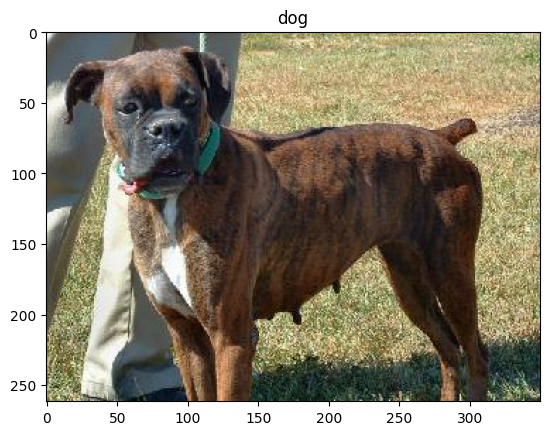

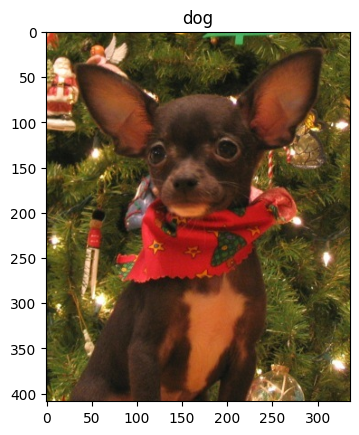

In [3]:
#EDA 이미지 크기 상이
import matplotlib.pyplot as plt
get_label_name = metadata.features['label'].int2str

for image, label in raw_train.take(2):
    plt.figure()    #이미지 여러개 한번에 나오게 함
    plt.imshow(image)
    plt.title(get_label_name(label))

In [5]:
#모델 내에서 데이터가 들어오면 layer에서 resize 
tf.keras.layers.experimental.preprocessing.Resizing

keras.layers.preprocessing.image_preprocessing.Resizing

In [6]:
#데이터 자체를 변화시킴 :tf.image :tf.data.Dataset 만들면  tensor로 데이터 관리, 기능 상속해서 prefetch 등으로 최적 학습 요건 만듦 
tf.image.resize

<function tensorflow.python.ops.image_ops_impl.resize_images_v2(images, size, method='bilinear', preserve_aspect_ratio=False, antialias=False, name=None)>

전체 데이터 변환 적용
- for :비효율적
- map :함수형 패러다임

In [7]:
#이미지 크기 맞춤 : resize, crop
IMG_SIZE = 160 # 모든 이미지는 160x160으로 크기가 조정

def format_example(image, label):
    image = tf.cast(image, tf.float32) #타입 변경
    image = (image/127.5) - 1          # zero-centered [-1,1 ] (AlexNEt,2012)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE)) #160,160크기로 맞춤
    return image, label

In [8]:
train = raw_train.map(format_example)
validation = raw_validation.map(format_example)
test = raw_test.map(format_example)
train

<MapDataset element_spec=(TensorSpec(shape=(160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [9]:
# Batch 처리 : tensor로 데이터 관리
BATCH_SIZE = 32
SHUFFL_BUFFER_SIZE =1000
# tf.data prefetch(AUTOTUNE)도 가능

train_batches = train.shuffle(SHUFFL_BUFFER_SIZE).batch(BATCH_SIZE)
validation_batches = validation.batch(BATCH_SIZE)
test_batches = test.batch(BATCH_SIZE)

In [10]:
for image_batch,label_batch in train_batches.take(1):
    pass
image_batch.shape  #데이터 검사 160x 160 색 이미지 32

TensorShape([32, 160, 160, 3])

In [11]:
IMG_SHAPE = (IMG_SIZE,IMG_SIZE,3)

base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                              include_top=False,
                                              weights='imagenet')

9406464/9406464 [==============================] - 1s 0us/step


In [12]:
base_model.trainable = False

In [13]:
base_model.summary()

Model: "mobilenetv2_1.00_160"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 160, 160, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 80, 80, 32)   864         ['input_1[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 80, 80, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)              (None, 80, 80, 32)   0           ['bn_Conv1[0][

ImageNet 학습한 모델은 많은 데이터로 학습했기 때문에 어느정도 성능 보장하기 때문에 예측 부분만 바꿈  
    - Global Average Pooling  
    - Fully connected neural network  
      - NFL : 데이터가 작은 경우 GAP(Global Average Pooling), 많으면 FCNN  
      - CNN에서 feature extraction 성능 좋으면 마지막은 FCNN 2개 정도 사용  

In [14]:
# multi-inputs, multi outputs 모델도 Sequential 내부에 들어가 하나처럼 사용 가능
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1)
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_160 (Funct  (None, 5, 5, 1280)       2257984   
 ional)                                                          
                                                                 
 flatten (Flatten)           (None, 32000)             0         
                                                                 
 dense (Dense)               (None, 1)                 32001     
                                                                 
Total params: 2,289,985
Trainable params: 32,001
Non-trainable params: 2,257,984
_________________________________________________________________


In [15]:
model.compile(optimizer='adam',  metrics=['accuracy'],
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True))
# from_logits=True 하면 활성화 함수 사용하지 않아도 numerical stability 제공하여 성능 안정적    

In [16]:
initial_epochs = 10
validation_steps = 20
loss0,accuracy0 = model.evaluate(validation_batches,steps=validation_steps)
# accuracy : 0.4922

20/20 [==============================] - 6s 33ms/step - loss: 1.1113 - accuracy: 0.3625


In [17]:
# RTX 3060 약 6분 소요
# 데이터 3,000개임에도 성능이 좋음 ; val acc 98.28% (or 97.64%)
# NFL :상황에 따라서 accuracy vs  traniable parameters
history = model.fit(train_batches,
                   epochs=initial_epochs,
                   validation_data=validation_batches)

Epoch 1/10
582/582 [==============================] - 36s 57ms/step - loss: 0.1745 - accuracy: 0.9724 - val_loss: 0.1065 - val_accuracy: 0.9854
Epoch 2/10
582/582 [==============================] - 35s 60ms/step - loss: 0.0840 - accuracy: 0.9873 - val_loss: 0.2178 - val_accuracy: 0.9785
Epoch 3/10
582/582 [==============================] - 35s 59ms/step - loss: 0.0322 - accuracy: 0.9943 - val_loss: 0.1677 - val_accuracy: 0.9815
Epoch 4/10
582/582 [==============================] - 36s 61ms/step - loss: 0.0252 - accuracy: 0.9955 - val_loss: 0.2067 - val_accuracy: 0.9807
Epoch 5/10
582/582 [==============================] - 36s 61ms/step - loss: 0.0187 - accuracy: 0.9959 - val_loss: 0.2892 - val_accuracy: 0.9781
Epoch 6/10
582/582 [==============================] - 35s 59ms/step - loss: 0.0207 - accuracy: 0.9966 - val_loss: 0.2445 - val_accuracy: 0.9815
Epoch 7/10
582/582 [==============================] - 36s 60ms/step - loss: 0.0252 - accuracy: 0.9965 - val_loss: 0.2814 - val_accuracy:

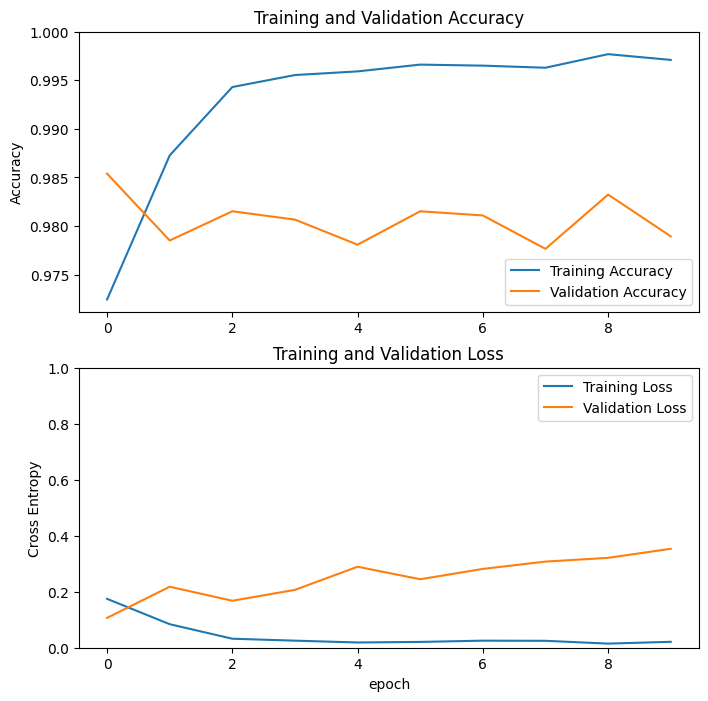

In [18]:
#정확한 비교를 위해서 그래프
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()


# 해석1: train /val accuracy가 크게 요동치지 않음(약 0.002 정도 차이) 
#      파라미터가 많아서 데이터가 더 많이 필요함 , test 데이터가 적기 때문
# 해석2: loss는 FCNN이 train, validation 차이가 큼
# 학습 파라미터 비교
#  - GAP 사용시 Trainable params: 1,281
#  - FCNN 사용시 Trainable params: 32,001  

<Axes: >

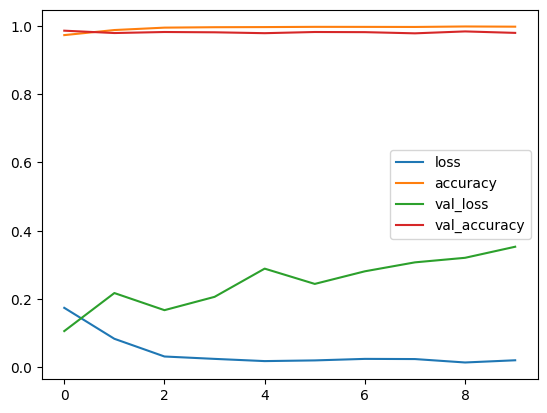

In [19]:
import pandas as pd
pd.DataFrame(history.history).plot.line() #전체적인 비교 한눈에 함

- [전이학습](https://www.tensorflow.org/guide/keras/transfer_learning)

1. 기본 모델을 인스턴스화하고 사전 훈련 된 가중치를 여기에 로드합니다.
    - data 크기, 모델 유사도기반으로 결정
2. `trainable = False` 를 설정하여 기본 모델의 모든 레이어를 고정합니다.(True 기본값)
    - 학습 시키지 않을 레이어 지정
3. 기본 모델에서 하나 (또는 여러) 레이어의 출력 위에 새 모델을 만듭니다.
4. 새 데이터 세트에서 새 모델을 학습시킵니다.

## Incremental Learning
-  이미 학습된 지식이 있는 모델 기반으로 비슷한 능력을 갖을수 있도록 해주는것이 공통점 떄문에 전이학습과 개념이 비슷하여 혼동

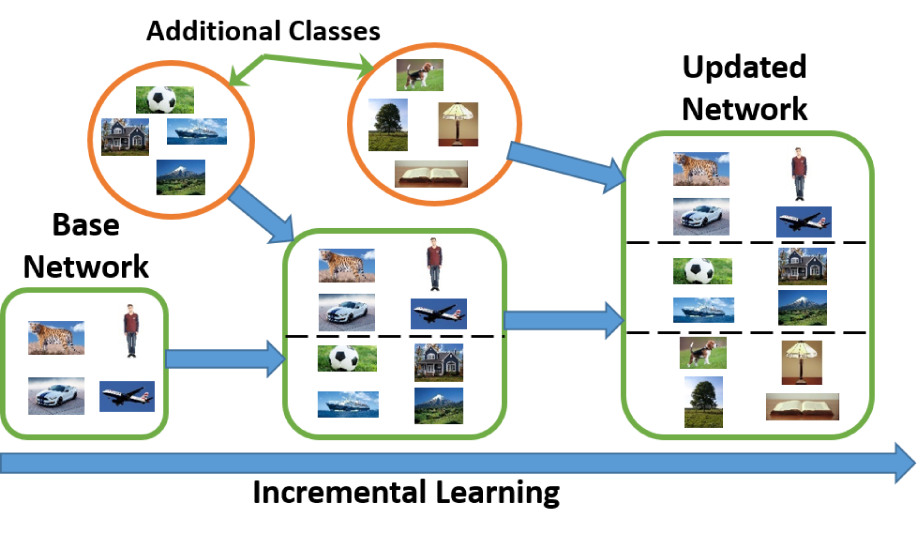
- n개 분류하는 모델에 새로운 클래스를 추가 학습하여 더 많은 클래스를 분류하도록 모델에 추가함
  > Transfer Learning : 학습된 모델을 가져와서 새로운 도메인에 적용

keras는 학습한 상황을 기준으로 추가되어 학습됨( scikit과 다름)

### Catastrophic Forgetting/inference
 - Incremental Learning 새로운거 학습하면서 이전에 잘 배운것을 못하게 되어 아예 처음부터 학습시키는 것이 더 성능이 좋은 경우가 많음

### Knowledge Distillation
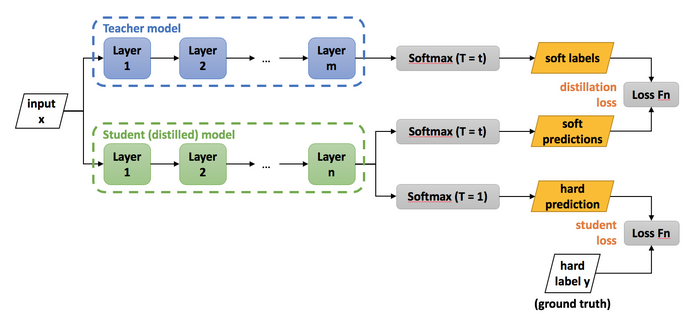
-  Incremental Learning 하위 기법(2016): 기존에 선생님이 갖는 지식에 새로운 데이터를 넣어 추가하여 기능 확장 시킴
- 학습할 때 선생님을 모셔와서 불 필요한 지식을 증류시키고 필요한 지식만 가져올 수 있도록 학생에게 도움을 줌으로써 간단한 모델에서도 좋은 성능 나옴
    - 모델 학습된 것을 갖고 있지만 학습된 데이터를 갖고있지 않아서 처음부터 학습시키는것은 불가..
    > distillation(증류) : 불순물이 섞여 있는 혼합물에서 원하는 특정 성분을 분리시키는 방법
    - NN에서 불필요하게 많은 파라미터가 사용되는 경우 ensemble model로부터 일반화 성능을 기존 대비 향상시킬수 있는 지식을 분리해냄

참고 : Knowledge_Distillation_Notebook.ipynb


--- 
논문: An Empirical Investigation of Catastrophic Forgetting in Gradient-Basesd Neural Networks by Ian Goodfellow
- Abstract:  Catastrophic Forgetting : 머신러닝 모델과 알고리즘에서 나오는 문제(NFL, 경험적), 특히 NN
- 한 태스크 학습하고나서 두번째 태스크를 학습시키면 이전에 배운것을 **잊어버림**
- classifier를 fine tunning 하는 이유
- **해결책: dropout**

In [20]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# 데이터셋 로드
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 데이터 전처리
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Teacher 모델 정의
teacher_input = Input(shape=(784,))
x = Dense(512, activation='relu')(teacher_input)
x = Dropout(0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(10, activation='softmax')(x)
teacher_model = Model(teacher_input, x)

# Teacher모델 학습
teacher_model.compile(loss='categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])
teacher_model.fit(x_train, y_train,
                  epochs=5, # 20
                  batch_size=128,
                  validation_data=(x_test, y_test))

Epoch 1/5
469/469 [==============================] - 2s 4ms/step - loss: 3.1021 - accuracy: 0.8667 - val_loss: 0.4678 - val_accuracy: 0.9416
Epoch 2/5
469/469 [==============================] - 2s 4ms/step - loss: 0.5118 - accuracy: 0.9198 - val_loss: 0.1950 - val_accuracy: 0.9518
Epoch 3/5
469/469 [==============================] - 2s 4ms/step - loss: 0.2697 - accuracy: 0.9377 - val_loss: 0.1669 - val_accuracy: 0.9543
Epoch 4/5
469/469 [==============================] - 2s 4ms/step - loss: 0.2087 - accuracy: 0.9485 - val_loss: 0.1605 - val_accuracy: 0.9577
Epoch 5/5
469/469 [==============================] - 2s 5ms/step - loss: 0.1733 - accuracy: 0.9550 - val_loss: 0.1292 - val_accuracy: 0.9651


In [21]:
# Student 모델 정의
student_input = Input(shape=(784,))
x = Dense(256, activation='relu')(student_input)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(10, activation='softmax')(x)
student_model = Model(student_input, x)

# Teacher 모델의 출력을 학습 데이터로 활용하여 Student모델에 지식 적용
teacher_output = teacher_model(x_train)
student_model.compile(loss='categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])
student_model.fit(x_train, teacher_output,
                  epochs=5,  # 20
                  batch_size=128,
                  validation_data=(x_test, y_test))

Epoch 1/5
469/469 [==============================] - 2s 4ms/step - loss: 3.8170 - accuracy: 0.7899 - val_loss: 0.5206 - val_accuracy: 0.8919
Epoch 2/5
469/469 [==============================] - 2s 4ms/step - loss: 0.6536 - accuracy: 0.8640 - val_loss: 0.3744 - val_accuracy: 0.9206
Epoch 3/5
469/469 [==============================] - 2s 4ms/step - loss: 0.4905 - accuracy: 0.8952 - val_loss: 0.3280 - val_accuracy: 0.9303
Epoch 4/5
469/469 [==============================] - 2s 5ms/step - loss: 0.4190 - accuracy: 0.9095 - val_loss: 0.2848 - val_accuracy: 0.9386
Epoch 5/5
469/469 [==============================] - 3s 5ms/step - loss: 0.3550 - accuracy: 0.9228 - val_loss: 0.2518 - val_accuracy: 0.9403


| 기술                     | 한 줄 설명              |
| ---------------------- | ------------------- |
| Transfer Learning      | 이미 배운 모델을 새 문제에 활용  |
| Incremental Learning   | 기존 모델이 계속 새로운 것을 학습 |
| Knowledge Distillation | 큰 모델 지식을 작은 모델에 전달  |


| 구분           | Transfer Learning (전이학습)       | Incremental Learning (Continual Learning) | Knowledge Distillation (KD) |
| ------------ | ------------------------------ | ----------------------------------------- | --------------------------- |
| 핵심 목적        | 기존 지식 재사용                      | 지속적 추가 학습                                 | 큰 모델 압축                     |
| 기본 개념        | pretrained 모델 활용               | 기존 모델 계속 업데이트                             | Teacher → Student 학습        |
| 주요 목표        | 빠른 학습 및 성능 향상                  | 새로운 데이터 지속 반영                             | 작은 모델 경량화                   |
| 학습 대상        | 새 Task                         | 시간에 따라 추가되는 데이터                           | 작은 Student 모델               |
| 기존 모델 사용 방식  | 일부/전체 재사용                      | 계속 유지하며 업데이트                              | Teacher 역할                  |
| 데이터 형태       | 새 데이터셋                         | 순차적 신규 데이터                                | Teacher 출력 + 정답             |
| 대표 문제        | Domain mismatch                | Catastrophic Forgetting                   | 성능 손실 가능                    |
| 모델 크기 변화     | 거의 동일                          | 동일                                        | 작아짐                         |
| 학습 비용        | 낮음                             | 중간~높음                                     | 높음                          |
| 대표 사용 분야     | Fine-tuning                    | 로봇/Agent/Edge AI                          | 모바일 AI/LLM 압축               |
| 기존 지식 유지     | 대부분 유지                         | 자주 잊어버림                                   | Teacher 지식 전달               |
| 학습 속도        | 빠름                             | 지속적 학습 필요                                 | 추가 학습 필요                    |
| 대표 기술        | Fine-tuning                    | Replay Buffer, EWC                        | Soft Label, Feature KD      |
| 대표 모델 예      | ResNet Fine-tuning             | Continual Transformer                     | DistilBERT                  |
| 산업 활용도       | 매우 높음                          | 제한적                                       | 매우 높음                       |
| 최근 중요도       | 매우 높음                          | 연구 활발                                     | 매우 높음                       |
| LLM 시대 활용    | Adapter, LoRA                  | Agent Memory                              | Small LLM 제작                |
| Vision AI 활용 | ImageNet 전이학습                  | 온라인 학습                                    | MobileNet 압축                |
| 대표 흐름        | Foundation Model → Fine-tuning | 지속 데이터 업데이트                               | Large Model → Small Model   |
| 핵심 키워드       | 재사용                            | 지속학습                                      | 압축                          |
